# Phase 15 — Ecoli Antibiotic Evaluation

**Project:** “Machine Learning approaches for accelerating antibiotic susceptibility testing (AST) in microfluidic systems” 

**Date:** May 2026 

## 1. Introduction

This notebook evaluates the ability of machine learning models to generalise across different antibiotics. Models are trained using data from a subset of antibiotics and subsequently tested on unseen antibiotics to assess whether the learned growth patterns are transferable across antimicrobial treatments.

### Objectives

- Evaluate the generalisation capability of machine learning models across antibiotics
- Assess model performance on antibiotics not included during training
- Compare the transferability of growth-related patterns between antibiotics
- Identify whether the engineered features capture antibiotic-independent growth dynamics

### Input
- `ecoli_data_ml.csv` 

## Table of Contents
1. [Introduction](#1-introduction)
2. [Imports & Setup](#2-imports--setup)
3. [Data Loading and preparation](#3-data-loading--preparation)
4. [Train / Test split](#4-train--test-split)
4. [Ampliciline](#5-ampliciline)
4. [Ciprofloxacin](#6-ciprofloxacin)
4. [Gentamicin](#7-gentamicin)
4. [Tetracycline](#8-tetracycline)
4. [Trimethoprim](#9-trimethoprim)

## 2. Imports & Setup

In [ ]:
# -- Data manipulation --------
import numpy as np
import pandas as pd

# -- Machine learning ---------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -- Visualisation ------------
import matplotlib.pyplot as plt

## 3. Data Loading & Preparation

### 3.1 Load dataset

In [20]:
# Load the labelled feature matrix from Phase 2
for_ml = pd.read_csv("ecoli_data_ml.csv")

print(f"Dataset shape: {for_ml.shape}")
for_ml.head()

Dataset shape: (45342, 14)


,experiencia,tubo_id,antibiotico,concentração,tempo,gvr,std_inicial,std_atual,std_tubo,slope,delta,AUC,Derivada,label
0,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.000000,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.000000,0.000000,1
1,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.166667,0.069883,0.008784,0.008784,0.000000,0.000000,0.000000,0.011647,0.000000,1
2,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.333333,-0.139765,0.008784,0.017568,0.098829,-0.628944,-0.209648,0.005824,-1.257887,1
3,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.500000,-0.199132,0.008784,0.025127,0.121492,-0.538028,-0.269014,-0.022418,-0.356198,1
4,ampicillin_20230508_5e6,ampicillin_20230508_5e6_0,ampicillin,0.0,0.666667,-0.119479,0.008784,0.024350,0.112185,-0.284042,-0.189362,-0.048969,0.477916,1


### 3.2 Clean and prepare

In [21]:
# Remove outlier experiment identified in Phase 3
df_ml = for_ml[for_ml["experiencia"] != "ampicillin_20230518_5e5"]

# Drop non-informative columns
df_ml = df_ml.drop(columns=["antibiotico", "concentração"])

print(f"Dataset shape after cleaning: {df_ml.shape}")

Dataset shape after cleaning: (44352, 12)


In [22]:
columns  = list(df_ml.columns)
Features = columns[2:-1]
label    = columns[-1]

print("Features:", Features)

Features: ['tempo', 'gvr', 'std_inicial', 'std_atual', 'std_tubo', 'slope', 'delta', 'AUC', 'Derivada']


In [23]:
experiencias = df_ml["experiencia"].unique()
experiencias

array(['ampicillin_20230508_5e6', 'ampicillin_20230508_5e5',
       'ampicillin_20230508_5e4', 'ampicillin_20230516_5e6',
       'ampicillin_20230516_5e5', 'ampicillin_20230516_5e4',
       'ampicillin_20230518_5e6', 'ampicillin_20230518_5e4',
       'ciprofloxacin_20250717_5e5', 'ciprofloxacin_20250719_5e5',
       'ciprofloxacin_20250728_5e5', 'gentamicin_20250717_5e5',
       'gentamicin_20250719_5e5', 'gentamicin_20250728_5e5',
       'tetracycline_20240118_5e6', 'tetracycline_20240118_5e4',
       'tetracycline_20240118_5e5', 'tetracycline_20240126_5e6',
       'tetracycline_20240126_5e5', 'tetracycline_20240126_5e4',
       'tetracycline_20240203_5e6', 'tetracycline_20240203_5e5',
       'tetracycline_20240203_5e4', 'trimethoprim_20250717_5e5',
       'trimethoprim_20250719_5e5', 'trimethoprim_20250728_5e5'],
      dtype=object)

## 4 Train / Test Split

In [ ]:
#Experiences
exp_teste1 = "ampicillin_20230518_5e4"
exp_teste2 = "ciprofloxacin_20250719_5e5"
exp_teste3 = "gentamicin_20250728_5e5"
exp_teste4 = "tetracycline_20240203_5e5"
exp_teste5 = "trimethoprim_20250717_5e5"

In [ ]:
experiencias = df_ml["experiencia"].unique()

# train
df_train = df_ml[~df_ml["experiencia"].isin([exp_teste1, exp_teste2, exp_teste3, exp_teste4, exp_teste5])]

# test 1 and test 2
df_test1 = df_ml[df_ml["experiencia"] == exp_teste1]
df_test2 = df_ml[df_ml["experiencia"] == exp_teste2]
df_test3 = df_ml[df_ml["experiencia"] == exp_teste3]
df_test4 = df_ml[df_ml["experiencia"] == exp_teste4]
df_test5 = df_ml[df_ml["experiencia"] == exp_teste5]

X_train = df_train[Features]
y_train = df_train["label"]

X_test1 = df_test1[Features]
y_test1 = df_test1["label"]

X_test2 = df_test2[Features]
y_test2 = df_test2["label"]

X_test3 = df_test3[Features]
y_test3 = df_test3["label"]

X_test4 = df_test4[Features]
y_test4 = df_test4["label"]

X_test5 = df_test5[Features]
y_test5 = df_test5["label"]

print(f"Train size : {len(X_train)} rows")
print(f"Test 1 size: {len(df_test1)} rows  ({exp_teste1})")
print(f"Test 2 size: {len(df_test2)} rows  ({exp_teste2})")
print(f"Test 3 size: {len(df_test3)} rows  ({exp_teste3})")
print(f"Test 4 size: {len(df_test4)} rows  ({exp_teste4})")
print(f"Test 5 size: {len(df_test5)} rows  ({exp_teste5})") 

Train size : 35850 rows
Test 1 size: 990 rows  (ampicillin_20230518_5e4)
Test 2 size: 2350 rows  (ciprofloxacin_20250719_5e5)
Test 3 size: 1270 rows  (gentamicin_20250728_5e5)
Test 4 size: 1750 rows  (tetracycline_20240203_5e5)
Test 5 size: 2142 rows  (trimethoprim_20250717_5e5)


In [25]:
print(f"Testeset ampliciline shape after: {df_test1.shape}")
print(f"Testeset ciprofloxacin shape after: {df_test2.shape}")
print(f"Testeset gentamicin shape after: {df_test3.shape}")
print(f"Testeset tetracycline shape after: {df_test4.shape}")
print(f"Testeset trimetroprim shape after: {df_test5.shape}")
print(f"Train set shape after: {X_train.shape}")

Testeset ampliciline shape after: (990, 12)
Testeset ciprofloxacin shape after: (2350, 12)
Testeset gentamicin shape after: (1270, 12)
Testeset tetracycline shape after: (1750, 12)
Testeset trimetroprim shape after: (2142, 12)
Train set shape after: (35850, 9)


## 5. Amplicilina

In [26]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Filter timepoints with sufficient signal variability
timepoints = df_test1[df_test1["std_atual"] > 0.05]["tempo"].unique()

accuracies_ampli = []

for t in timepoints:
    df_t  = df_test1[df_test1["tempo"] == t]
    X_t   = df_t[Features]
    y_t   = df_t[label]

    preds = model.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_ampli.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t}h  |  Accuracy: {acc}")
    print(result.to_string(index=False), "\n")

Time: 5.500000000000001h  |  Accuracy: 0.5
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          0
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.833333333333335h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 6.000000000000002h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          0
    0          1
    0          0
    0          1
    0          1
    0          0 

Time: 6.166666666666669h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          0
    0          1
    0          0
    0          1
    0          1
    0          0 

Time: 6.333333333333336h  |  Accuracy: 0.6
 real  predicted
    1       

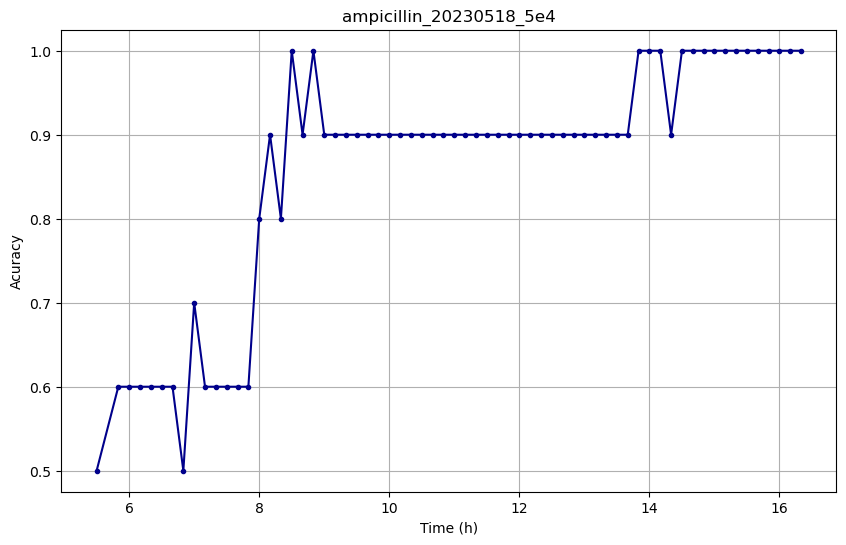

In [27]:
df_results = pd.DataFrame(accuracies_ampli)
df_results = df_results.sort_values(by="time")

plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("ampicillin_20230518_5e4")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

## 6. Ciprofloxacin

In [28]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Filter timepoints with sufficient signal variability
timepoints = df_test2[df_test2["std_atual"] > 0.05]["tempo"].unique()

accuracies_ciprofloxacin = []

for t in timepoints:
    df_t  = df_test2[df_test2["tempo"] == t]
    X_t   = df_t[Features]
    y_t   = df_t[label]

    preds = model.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_ciprofloxacin.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t}h  |  Accuracy: {acc}")
    print(result.to_string(index=False), "\n")

Time: 0.6666666666666666h  |  Accuracy: 0.3
 real  predicted
    0          1
    0          1
    0          1
    0          1
    0          1
    1          1
    1          1
    1          0
    1          0
    1          1 

Time: 0.8333333333333333h  |  Accuracy: 0.4
 real  predicted
    0          1
    0          1
    0          1
    0          1
    0          0
    1          1
    1          1
    1          0
    1          0
    1          1 

Time: 1.3333333333333333h  |  Accuracy: 0.5
 real  predicted
    0          0
    0          0
    0          1
    0          1
    0          0
    1          1
    1          0
    1          0
    1          0
    1          1 

Time: 2.0h  |  Accuracy: 0.6
 real  predicted
    0          1
    0          0
    0          1
    0          0
    0          0
    1          1
    1          1
    1          0
    1          0
    1          1 

Time: 2.5h  |  Accuracy: 0.6
 real  predicted
    0          1
    0          0
   

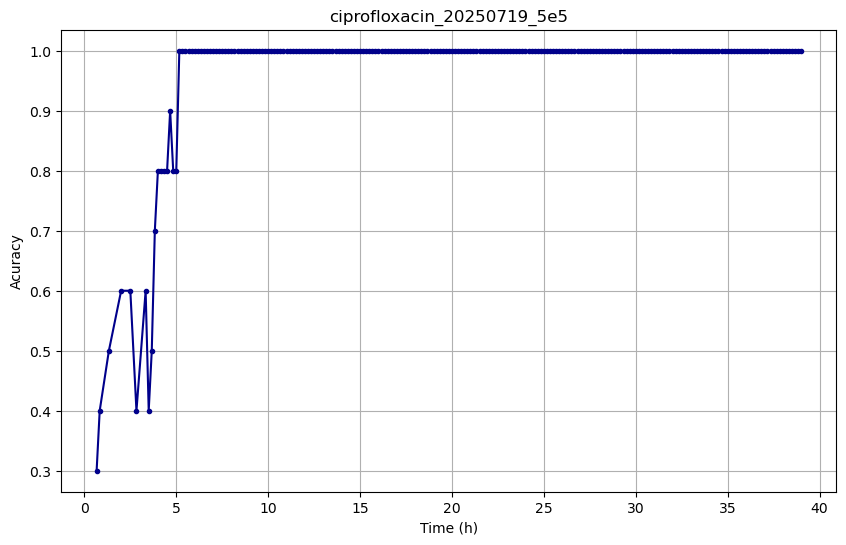

In [29]:
# 1. Transformar a lista em DataFrame
df_results = pd.DataFrame(accuracies_ciprofloxacin)

# 2. Ordenar por tempo para garantir que a linha do gráfico fique correta
df_results = df_results.sort_values(by="time")

# 3. Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("ciprofloxacin_20250719_5e5")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

## 7. Gentamicin

In [30]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Filter timepoints with sufficient signal variability
timepoints = df_test3[df_test3["std_atual"] > 0.05]["tempo"].unique()

accuracies_gentamicin = []

for t in timepoints:
    df_t  = df_test3[df_test3["tempo"] == t]
    X_t   = df_t[Features]
    y_t   = df_t[label]

    preds = model.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_gentamicin.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t}h  |  Accuracy: {acc}")
    print(result.to_string(index=False), "\n")

Time: 3.833333333333332h  |  Accuracy: 0.5
 real  predicted
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1
    1          1
    1          1
    1          1
    1          1 

Time: 3.9999999999999982h  |  Accuracy: 0.5
 real  predicted
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1
    1          1
    1          1
    1          1
    1          1 

Time: 4.166666666666665h  |  Accuracy: 0.5
 real  predicted
    1          1
    0          1
    0          1
    0          1
    0          1
    0          1
    1          1
    1          1
    1          1
    1          1 

Time: 4.333333333333332h  |  Accuracy: 0.6
 real  predicted
    1          1
    0          1
    0          1
    0          1
    0          0
    0          1
    1          1
    1          1
    1          1
    1          1 

Time: 4.499999999999999h  |  Accuracy: 0.5
 real  predicted
    1      

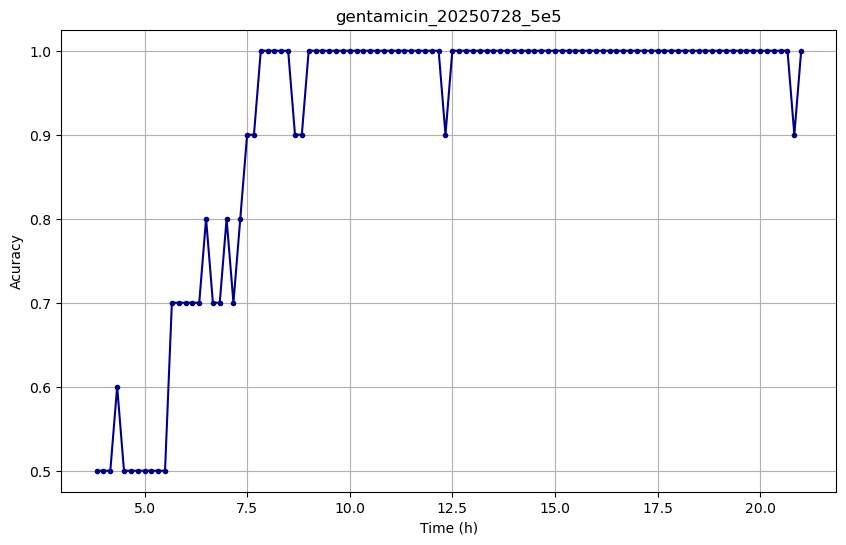

In [31]:
# 1. Transformar a lista em DataFrame
df_results = pd.DataFrame(accuracies_gentamicin)

# 2. Ordenar por tempo para garantir que a linha do gráfico fique correta
df_results = df_results.sort_values(by="time")

# 3. Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("gentamicin_20250728_5e5")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

## 8. Tetracycline

In [32]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Filter timepoints with sufficient signal variability
timepoints = df_test4[df_test4["std_atual"] > 0.05]["tempo"].unique()

accuracies_tetracycline = []

for t in timepoints:
    df_t  = df_test4[df_test4["tempo"] == t]
    X_t   = df_t[Features]
    y_t   = df_t[label]

    preds = model.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_tetracycline.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t}h  |  Accuracy: {acc}")
    print(result.to_string(index=False), "\n")

Time: 5.166666666666667h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.333333333333334h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.500000000000001h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.666666666666668h  |  Accuracy: 0.6
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    0          1
    0          1
    0          0 

Time: 5.833333333333335h  |  Accuracy: 0.6
 real  predicted
    1       

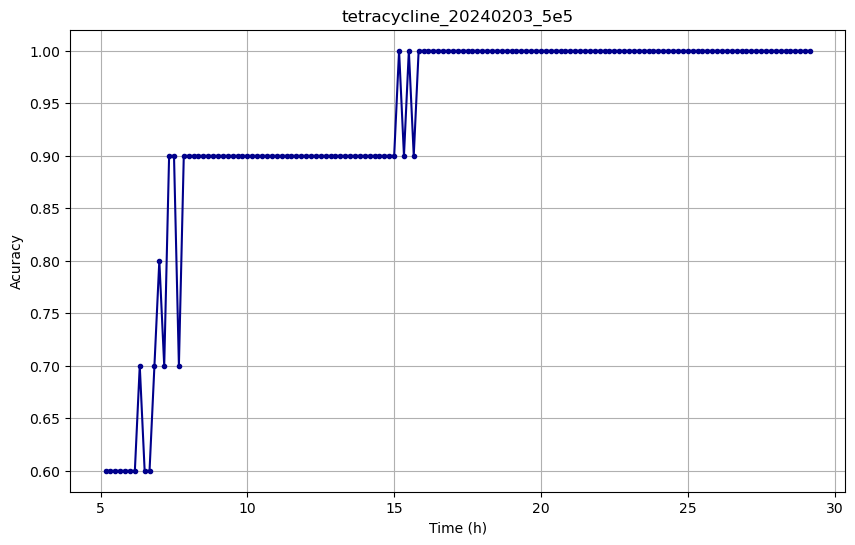

In [33]:
# 1. Transformar a lista em DataFrame
df_results = pd.DataFrame(accuracies_tetracycline)

# 2. Ordenar por tempo para garantir que a linha do gráfico fique correta
df_results = df_results.sort_values(by="time")

# 3. Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("tetracycline_20240203_5e5")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()

## 9. Trimethoprim

In [34]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Filter timepoints with sufficient signal variability
timepoints = df_test5[df_test5["std_atual"] > 0.05]["tempo"].unique()

accuracies_trimethoprim = []

for t in timepoints:
    df_t  = df_test5[df_test5["tempo"] == t]
    X_t   = df_t[Features]
    y_t   = df_t[label]

    preds = model.predict(X_t)
    acc   = accuracy_score(y_t, preds)
    accuracies_trimethoprim.append({"time": t, "accuracy": acc})

    result = pd.DataFrame({"real": y_t.values, "predicted": preds})
    print(f"Time: {t}h  |  Accuracy: {acc}")
    print(result.to_string(index=False), "\n")

Time: 0.8333333333333333h  |  Accuracy: 0.7777777777777778
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    1          1
    1          1 

Time: 1.0h  |  Accuracy: 0.7777777777777778
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    1          1
    1          1 

Time: 1.6666666666666667h  |  Accuracy: 0.6666666666666666
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    1          0
    1          1 

Time: 2.5h  |  Accuracy: 0.7777777777777778
 real  predicted
    1          1
    1          1
    1          1
    1          1
    1          1
    0          1
    0          1
    1          1
    1          1 

Time: 2.666666666666666h  |  Accuracy: 0.8888888888888888
 real  predicted
    1          1
    1         

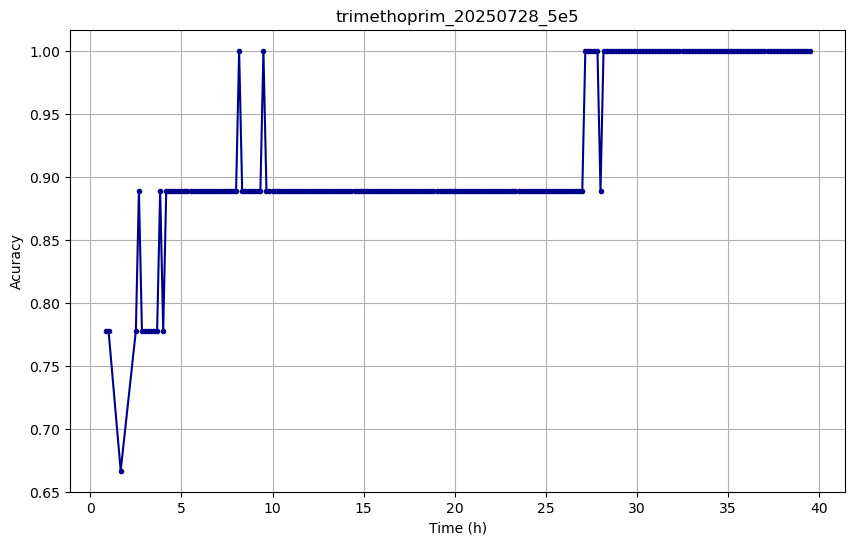

In [35]:
# 1. Transformar a lista em DataFrame
df_results = pd.DataFrame(accuracies_trimethoprim)

# 2. Ordenar por tempo para garantir que a linha do gráfico fique correta
df_results = df_results.sort_values(by="time")

# 3. Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_results["time"], df_results["accuracy"], marker='.', linestyle='-', color='darkblue')
plt.title("trimethoprim_20250728_5e5")
plt.xlabel("Time (h)")
plt.ylabel("Acuracy")
plt.grid(True)
plt.show()